# PM Accelerator Technical Assessment
## Weather Trend Forecasting

Author: Saifeddine Rejeb

Date: April 26, 2026

---
![PM Accelerator Logo](https://kajabi-storefronts-production.kajabi-cdn.com/kajabi-storefronts-production/file-uploads/themes/2158544136/settings_images/adb286e-70be-dca-28a-613833d61854__20241023211457.png)

### Our Mission

*By making industry-leading tools and education available to individuals from all backgrounds, we level the playing field for future PM leaders. This is the PM Accelerator motto, as we grant aspiring and experienced PMs what they need most – Access. We introduce you to industry leaders, surround you with the right PM ecosystem, and discover the new world of AI product management skills.*

---

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import shap
import kagglehub
import tensorflow as tf

from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

## 2. Data Loading

In [2]:
path = kagglehub.dataset_download("nelgiriyewithana/global-weather-repository")
print("Dataset path:", path)
print("Files:", os.listdir(path))

100%|██████████| 10.9M/10.9M [00:00<00:00, 12.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/nelgiriyewithana/global-weather-repository/versions/936
Files: ['state.db', 'GlobalWeatherRepository.csv']


In [40]:
path_data = os.path.join(path, "GlobalWeatherRepository.csv")
df = pd.read_csv(path_data)
print(f"Shape: {df.shape}")
df.head()

Shape: (137803, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## 3. Exploratory Data Analysis & Cleaning

### 3.1 Data Quality

In [41]:
print("=== dtypes ===")
print(df.dtypes)

=== dtypes ===
country                          object
location_name                    object
latitude                        float64
longitude                       float64
timezone                         object
last_updated_epoch                int64
last_updated                     object
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                   object
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles                float64
uv_index                 

In [42]:
print("=== Missing values ===")
df.isna().sum()

=== Missing values ===


,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


In [43]:
print("=== Duplicated rows ===")
df.duplicated().sum()

=== Duplicated rows ===


np.int64(0)

- No missing values and no duplicate rows across all features.

### 3.2 Object Column Audit

Identify which object columns encode numeric or datetime values so they can be cast correctly.

In [5]:
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
summary = []
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    numeric_try = pd.to_numeric(s, errors='coerce')
    datetime_try = pd.to_datetime(s, errors='coerce', utc=False)
    summary.append({
        'column': c,
        'unique': df[c].nunique(dropna=True),
        'numeric_parse_rate': round(numeric_try.notna().mean(), 3),
        'datetime_parse_rate': round(datetime_try.notna().mean(), 3),
        'sample_values': ', '.join(df[c].dropna().astype(str).head(3).tolist())
    })
pd.DataFrame(summary).sort_values(['numeric_parse_rate', 'datetime_parse_rate'], ascending=False)

/tmp/ipykernel_5430/1741366338.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime_try = pd.to_datetime(s, errors='coerce', utc=False)
/tmp/ipykernel_5430/1741366338.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime_try = pd.to_datetime(s, errors='coerce', utc=False)
/tmp/ipykernel_5430/1741366338.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime_try = pd.to_datetime(s, errors='coerce', utc=False)
/tmp/ipykernel_5430/1741366338.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. T

,column,unique,numeric_parse_rate,datetime_parse_rate,sample_values
3,last_updated,22925,0.0,1.000,"2024-05-16 13:15, 2024-05-16 10:45, 2024-05-16..."
6,sunrise,495,0.0,1.000,"04:50 AM, 05:21 AM, 05:40 AM"
7,sunset,547,0.0,1.000,"06:50 PM, 07:54 PM, 07:50 PM"
8,moonrise,1444,0.0,0.966,"12:12 PM, 12:58 PM, 01:15 PM"
9,moonset,1444,0.0,0.966,"01:11 AM, 02:14 AM, 02:14 AM"
0,country,211,0.0,0.000,"Afghanistan, Albania, Algeria"
1,location_name,257,0.0,0.000,"Kabul, Tirana, Algiers"
2,timezone,199,0.0,0.000,"Asia/Kabul, Europe/Tirane, Africa/Algiers"
4,condition_text,49,0.0,0.000,"Partly Cloudy, Partly cloudy, Sunny"
5,wind_direction,16,0.0,0.000,"NNW, NW, W"


**Observations:**
- `last_updated`, `sunrise`, and `sunset` parse cleanly as datetime (100% parse rate) and will be converted to structured time features.
- `moonrise` and `moonset` parse at ~96.6% — the remainder are likely "No moonrise/moonset" strings that will be filled with 0.
- `country`, `location_name`, `timezone`, `condition_text`, `wind_direction`, and `moon_phase` are true categoricals.


### 3.3 Data Cleaning

- Drop the redundant epoch column (already have `last_updated` as a string).
- Standardise country names that appear in multiple languages/transliterations.

In [6]:
# Drop redundant epoch column
df = df.drop('last_updated_epoch', axis=1)

In [7]:
# Identify rare country spellings (< 10 rows) before normalising
country_counts = df['country'].value_counts(dropna=False)
print("Rare country spellings:")
print(country_counts[country_counts < 10])

Rare country spellings:
country
USA United States of America        3
Lao People's Democratic Republic    1
Libya                               1
Kosovo                              1
Togo                                1
Malásia                             1
Komoren                             1
كولومبيا                            1
Colombia                            1
Estonie                             1
Гватемала                           1
Letonia                             1
Inde                                1
Mexique                             1
Polônia                             1
Marrocos                            1
Польша                              1
Турция                              1
Saint-Vincent-et-les-Grenadines     1
Südkorea                            1
Saudi Arabien                       1
Bélgica                             1
Turkménistan                        1
火鸡                                  1
Jemen                               1
Name: count, dtype

- Several country names appear in non-English scripts (Arabic, Russian, Portuguese, German, French)

In [8]:
# Normalize country names
translation = {
    'Malásia': 'Malaysia', 
    'كولومبيا': 'Colombia', 
    'Гватемала': 'Guatemala',
    'Польша': 'Poland', 
    'Polônia': 'Poland', 
    'Турция': 'Turkey',
    'Südkorea': 'South Korea', 
    'Bélgica': 'Belgium', 
    'Turkménistan': 'Turkmenistan',
    '火鸡': 'Turkey', 
    'USA United States of America': 'United States of America',
    'Komoren': 'Comoros', 
    'Estonie': 'Estonia', 
    'Inde': 'India',
    'Mexique': 'Mexico', 
    'Letonia': 'Latvia', 
    'Marrocos': 'Morocco',
    'Saudi Arabien': 'Saudi Arabia', 
    'Jemen': 'Yemen',
    'Saint-Vincent-et-les-Grenadines': 'Saint Vincent and the Grenadines',
    'Kyrghyzstan': 'Kyrgyzstan', 
    "Cote d'Ivoire": "Côte d'Ivoire"
}
df['country'] = df['country'].replace(translation)
print('Unique countries:', df['country'].nunique())

Unique countries: 191


### 3.4 Numeric Summary & Outlier Detection

For each numeric column, compute descriptive statistics and flag outliers via both the IQR rule and the Z-score rule (|z| > 3).

In [ ]:
# Calculating important measures for each numeric column
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Per-column quartiles and IQR
q1 = numeric_df.quantile(0.25)
q3 = numeric_df.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# IQR outlier mask/counts
iqr_outlier_mask = (numeric_df.lt(lower, axis=1)) | (numeric_df.gt(upper, axis=1))
iqr_outlier_counts = iqr_outlier_mask.sum()

# Z-score outlier mask/counts (abs(z) > 3)
z_scores = pd.DataFrame(
    stats.zscore(numeric_df, nan_policy='omit'),
    columns=numeric_df.columns,
    index=numeric_df.index
).abs()
z_outlier_mask = z_scores > 3
z_outlier_counts = z_outlier_mask.sum()

# Summary table like your original stats_df
stats_df = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Std': numeric_df.std(),
    'Min': numeric_df.min(),
    'Max': numeric_df.max(),
    'Range': numeric_df.max() - numeric_df.min(),
    'IQR': iqr,
    'Outliers-IQR': iqr_outlier_counts,
    'Outliers-ZScore': z_outlier_counts
}).reset_index(names='Column')

# Percentages for quick prioritization
stats_df['Outliers-IQR-%'] = (100 * stats_df['Outliers-IQR'] / len(df)).round(2)
stats_df['Outliers-ZScore-%'] = (100 * stats_df['Outliers-ZScore'] / len(df)).round(2)

# Sort by most problematic columns
stats_df = stats_df.sort_values(['Outliers-IQR', 'Outliers-ZScore'], ascending=False)

outlier_rows_iqr = {
    c: df.loc[iqr_outlier_mask[c], [c]].copy()
    for c in numeric_df.columns
}
outlier_rows_zscore = {
    c: df.loc[z_outlier_mask[c], [c]].copy()
    for c in numeric_df.columns
}

stats_df

,Column,Mean,Median,Std,Min,Max,Range,IQR,Outliers-IQR,Outliers-ZScore,Outliers-IQR-%,Outliers-ZScore-%
15,visibility_km,9.507689,10.0000,2.692913,0.000,32.000,32.000,0.0000,29532,4142,21.43,3.01
16,visibility_miles,5.616242,6.0000,1.682258,0.000,19.000,19.000,0.0000,29366,4318,21.31,3.13
9,precip_mm,0.133865,0.0000,0.560860,0.000,42.240,42.240,0.0300,25481,1952,18.49,1.42
10,precip_in,0.005073,0.0000,0.022168,0.000,1.660,1.660,0.0000,21240,1762,15.41,1.28
23,air_quality_Sulphur_dioxide,10.278280,2.4050,35.368065,-9999.000,521.330,10520.330,7.1400,18938,1301,13.74,0.94
25,air_quality_PM10,48.166512,19.8500,148.501486,-1848.150,6037.290,7885.440,31.3050,14690,1318,10.66,0.96
22,air_quality_Nitrogen_dioxide,14.942860,5.6500,23.587785,0.000,427.700,427.700,15.5500,14290,3424,10.37,2.48
27,air_quality_gb-defra-index,2.596518,2.0000,2.436361,1.000,10.000,9.000,2.0000,12997,8091,9.43,5.87
20,air_quality_Carbon_Monoxide,457.461781,292.3000,753.322375,-9999.000,38879.398,48878.398,256.6500,12353,1844,8.96,1.34
24,air_quality_PM2.5,24.088876,14.0600,36.652515,0.168,1614.100,1613.932,20.7000,11338,2127,8.23,1.54


**Observations:**

- `visibility_km` and `visibility_miles` have the highest IQR outlier count (~21-22% of rows) but this is expected, visibility varies enormously by weather event and is not a data error.
- `air_quality_Carbon_Monoxide` and `air_quality_Sulphur_dioxide` contain values of **-9999**, a sentinel for missing measurements. These should be treated as missing rather than true extremes.
- `precip_mm` and `precip_in` are heavily right-skewed (median = 0, max in the hundreds), precipitation is inherently sparse and bursty, so high IQR outlier counts here are expected.
- `gust_mph` and `gust_kph` show physically impossible maxima (~1845 mph / ~2970 kph). These are sensor errors and warrant capping or removal before modelling.
- `latitude`, `wind_degree`, `humidity`, `cloud`, and `moon_illumination` show **zero outliers**, they are bounded variables by definition.
- Z-score outliers are rare across the board (<4%), which suggests the distributions, while skewed, don't have extreme isolated spikes beyond the sensor errors noted above.

## 4. Feature Engineering

- Parse `last_updated` → calendar features (year, month, day, weekday, hour)
- Cyclically encode `hour` and `month` to preserve their periodic structure
- MinMax-scale all numeric features so they share the same [0, 1] range for the neural network
- Parse sunrise/sunset/moonrise/moonset strings to hour-of-day integers

In [10]:
scaler = MinMaxScaler()

# Parse datetime and extract calendar features
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['year']    = df['last_updated'].dt.year
df['month']   = df['last_updated'].dt.month
df['day']     = df['last_updated'].dt.day
df['weekday'] = df['last_updated'].dt.day_name()
df['hour']    = df['last_updated'].dt.hour

# Cyclical encoding keeps hour 23 → hour 0 distance small
df['Hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['Hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['Month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Columns to scale: all original numeric + the 4 cyclical encodings
numeric_df = df.select_dtypes(include=[np.number]).copy()
columns = numeric_df.columns.tolist() + ['Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos']
# deduplicate preserving order (Hour_sin etc. already added to df)
columns = list(dict.fromkeys(columns))

df_numeric_normalized = pd.DataFrame(
    scaler.fit_transform(df[columns]), columns=columns
)

# Combine with categorical columns
df_scaled = df.select_dtypes(exclude=['number']).copy()
df_scaled[columns] = df_numeric_normalized.values

print("Scaled dataframe shape:", df_scaled.shape)
df_scaled.head()

Scaled dataframe shape: (137803, 49)


,country,location_name,timezone,last_updated,condition_text,wind_direction,sunrise,sunset,moonrise,moonset,...,air_quality_gb-defra-index,moon_illumination,year,month,day,hour,Hour_sin,Hour_cos,Month_sin,Month_cos
0,Afghanistan,Kabul,Asia/Kabul,2024-05-16 13:15:00,Partly Cloudy,NNW,04:50 AM,06:50 PM,12:12 PM,01:11 AM,...,0.0,0.55,0.0,0.363636,0.5,0.565217,0.370590,0.017037,0.75,0.066987
1,Albania,Tirana,Europe/Tirane,2024-05-16 10:45:00,Partly cloudy,NW,05:21 AM,07:54 PM,12:58 PM,02:14 AM,...,0.0,0.55,0.0,0.363636,0.5,0.434783,0.750000,0.066987,0.75,0.066987
2,Algeria,Algiers,Africa/Algiers,2024-05-16 09:45:00,Sunny,W,05:40 AM,07:50 PM,01:15 PM,02:14 AM,...,0.0,0.55,0.0,0.363636,0.5,0.391304,0.853553,0.146447,0.75,0.066987
3,Andorra,Andorra La Vella,Europe/Andorra,2024-05-16 10:45:00,Light drizzle,SW,06:31 AM,09:11 PM,02:12 PM,03:31 AM,...,0.0,0.55,0.0,0.363636,0.5,0.434783,0.750000,0.066987,0.75,0.066987
4,Angola,Luanda,Africa/Luanda,2024-05-16 09:45:00,Partly cloudy,SSE,06:12 AM,05:55 PM,01:17 PM,12:38 AM,...,1.0,0.55,0.0,0.363636,0.5,0.391304,0.853553,0.146447,0.75,0.066987


In [11]:
def parse_time_to_hour(series):
    """Convert strings like '04:50 AM' to hour-of-day integers.
    Missing / unparseable values fall back to 0.
    """
    parsed = pd.to_datetime(series, format='%I:%M %p', errors='coerce')
    return parsed.dt.hour.fillna(0).astype(int)

for col in ['sunrise', 'sunset', 'moonrise', 'moonset']:
    df_scaled[col] = parse_time_to_hour(df[col])

df_scaled.head()

,country,location_name,timezone,last_updated,condition_text,wind_direction,sunrise,sunset,moonrise,moonset,...,air_quality_gb-defra-index,moon_illumination,year,month,day,hour,Hour_sin,Hour_cos,Month_sin,Month_cos
0,Afghanistan,Kabul,Asia/Kabul,2024-05-16 13:15:00,Partly Cloudy,NNW,4,18,12,1,...,0.0,0.55,0.0,0.363636,0.5,0.565217,0.370590,0.017037,0.75,0.066987
1,Albania,Tirana,Europe/Tirane,2024-05-16 10:45:00,Partly cloudy,NW,5,19,12,2,...,0.0,0.55,0.0,0.363636,0.5,0.434783,0.750000,0.066987,0.75,0.066987
2,Algeria,Algiers,Africa/Algiers,2024-05-16 09:45:00,Sunny,W,5,19,13,2,...,0.0,0.55,0.0,0.363636,0.5,0.391304,0.853553,0.146447,0.75,0.066987
3,Andorra,Andorra La Vella,Europe/Andorra,2024-05-16 10:45:00,Light drizzle,SW,6,21,14,3,...,0.0,0.55,0.0,0.363636,0.5,0.434783,0.750000,0.066987,0.75,0.066987
4,Angola,Luanda,Africa/Luanda,2024-05-16 09:45:00,Partly cloudy,SSE,6,17,13,0,...,1.0,0.55,0.0,0.363636,0.5,0.391304,0.853553,0.146447,0.75,0.066987


## 5. Exploratory Visualisations

### 5.1 Correlation Matrix

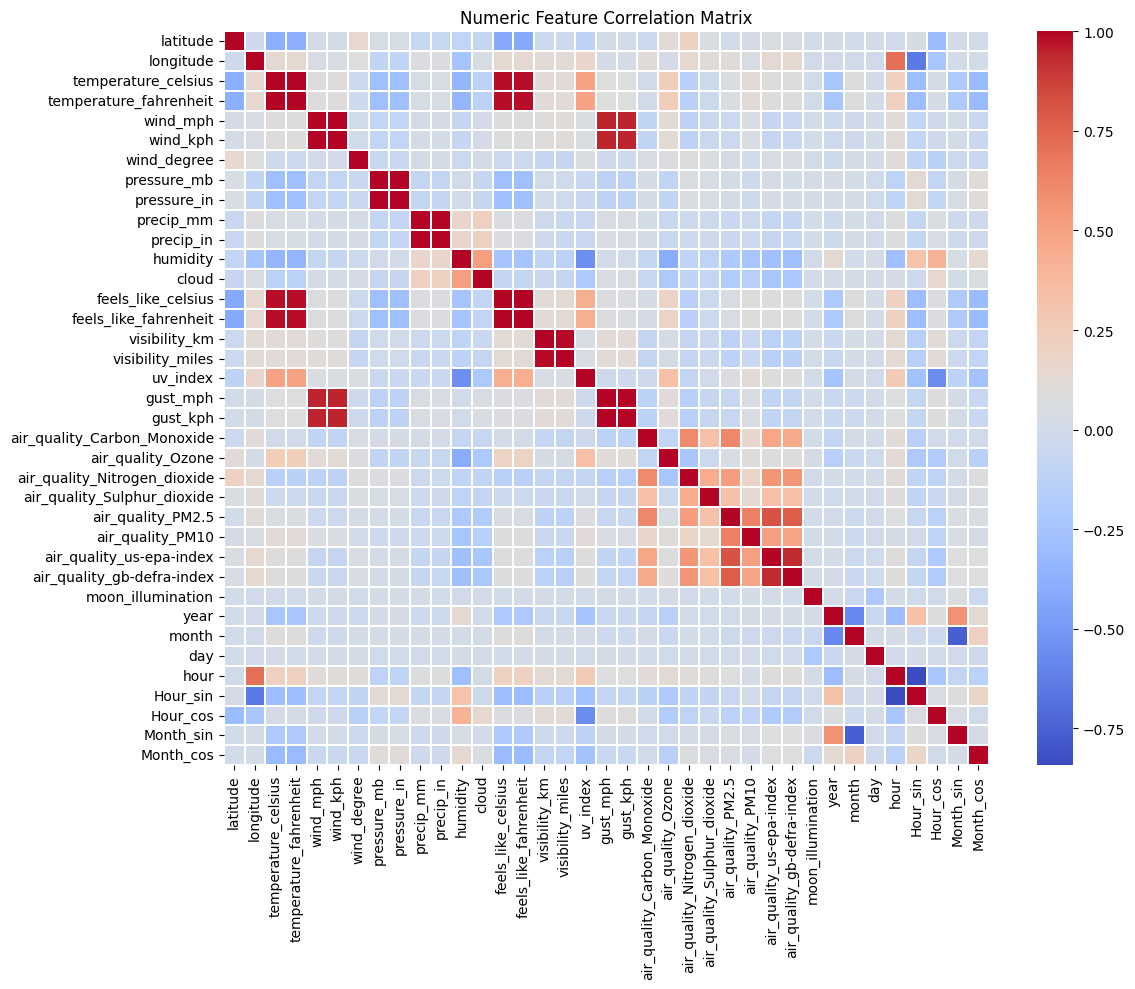

In [12]:
correlation_matrix = df_scaled[columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.3)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Observations:**

- The strongest correlations are between unit-duplicate pairs: `temperature_celsius`/`temperature_fahrenheit`, `wind_kph` / `wind_mph`, `pressure_mb` / `pressure_in`, `visibility_km` / `visibility_miles`, `gust_kph` / `gust_mph`, `feels_like_celsius` / `feels_like_fahrenheit`. These are perfectly collinear by construction — in a production model, one from each pair should be dropped.
- The air quality cluster (`CO`, `NO₂`, `SO₂`, `PM2.5`, `PM10`, `us-epa-index`, `gb-defra-index`) shows moderate internal correlation, suggesting a shared pollution signal.
- `Hour_sin` / `Hour_cos` and `Month_sin` / `Month_cos` show expected anti-correlation with each other this is the correct behaviour of cyclical encoding.
- Temperature features correlate positively with `uv_index` and negatively with `humidity`, matching physical intuition.
- Most air quality features are weakly correlated with meteorological variables, suggesting they carry independent signal.

### 5.2 Pairplot — Key Meteorological Variables

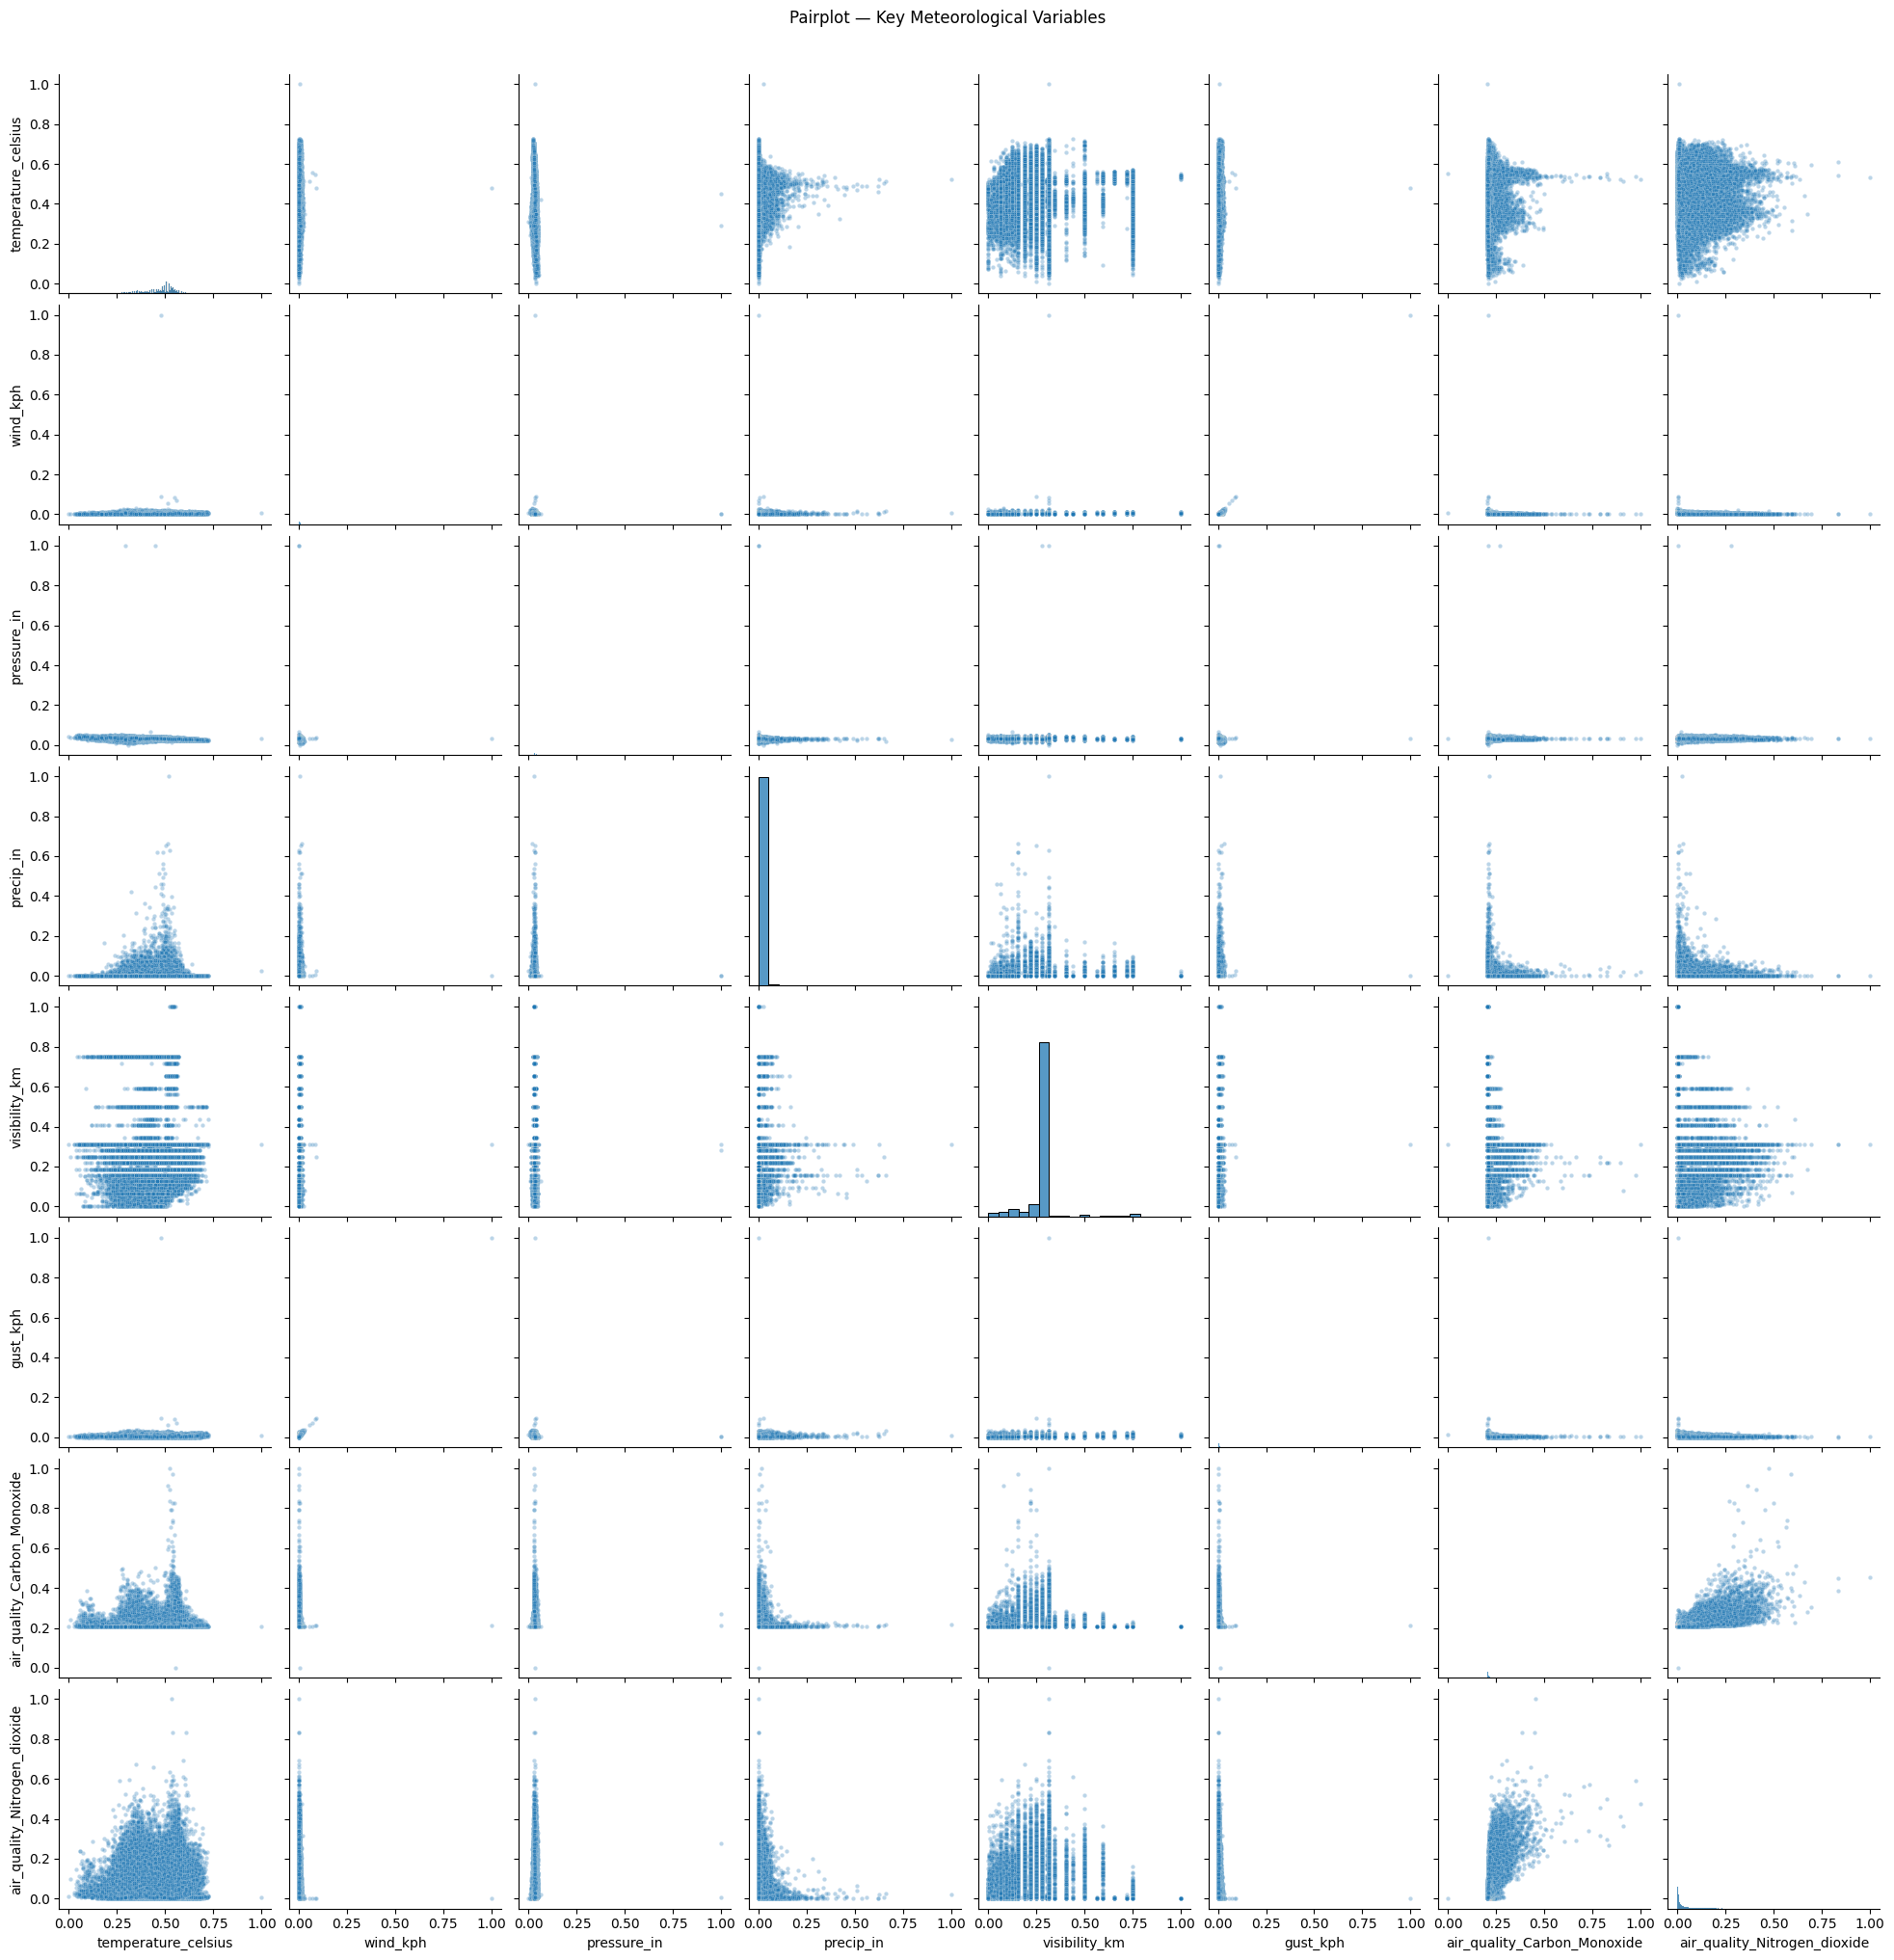

In [13]:
key_vars = ['temperature_celsius', 'wind_kph', 'pressure_in',
            'precip_in', 'visibility_km', 'gust_kph',
            'air_quality_Carbon_Monoxide', 'air_quality_Nitrogen_dioxide']
sns.pairplot(df_scaled[key_vars], plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle("Pairplot — Key Meteorological Variables", y=1.02)
plt.show()

**Observations:**

- The pairplot confirms heavy right-skew in `precip_in`, the vast majority of observations cluster near zero, with a long tail of precipitation events.
- `pressure_in` shows a bimodal-ish distribution, likely reflecting the mix of high-altitude and sea-level stations in a global dataset.
- `wind_kph` and `gust_kph` are strongly correlated and similarly skewed, with a handful of extreme values.
- No clear linear relationships emerge between air quality variables and meteorological ones, consistent with the correlation matrix.

### 5.3 Temperature Distribution

/tmp/ipykernel_5430/2477776188.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)


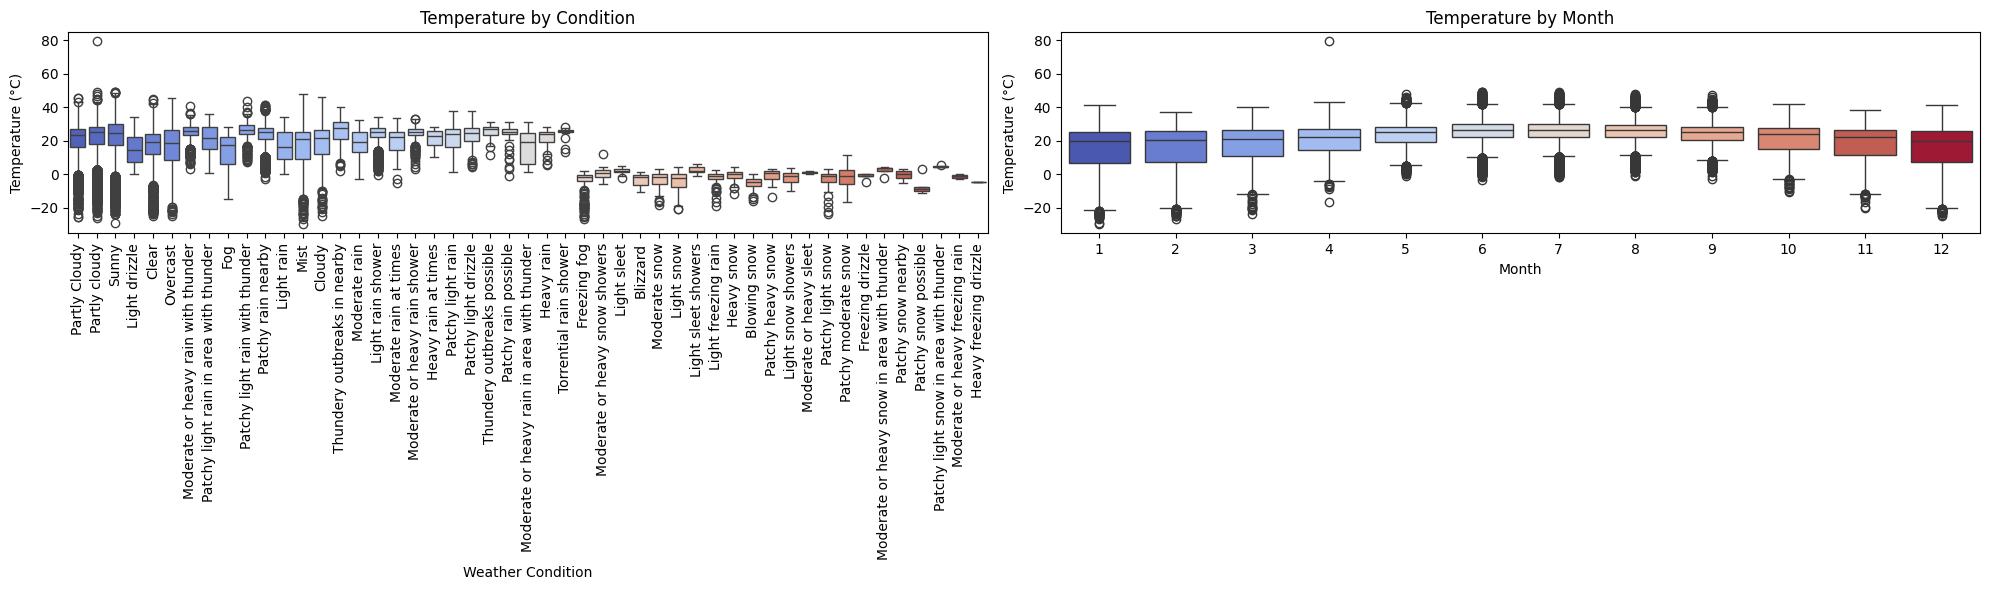

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.boxplot(x=df['condition_text'], y=df['temperature_celsius'],
            hue=df['condition_text'], palette='coolwarm', legend=False, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[0].set_xlabel("Weather Condition")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Temperature by Condition")

sns.boxplot(x=df['month'], y=df['temperature_celsius'],
            hue=df['month'], palette='coolwarm', legend=False, ax=axes[1])
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Temperature by Month")

plt.tight_layout()
plt.show()

### 5.4 Precipitation Distribution

/tmp/ipykernel_5430/2500533363.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)


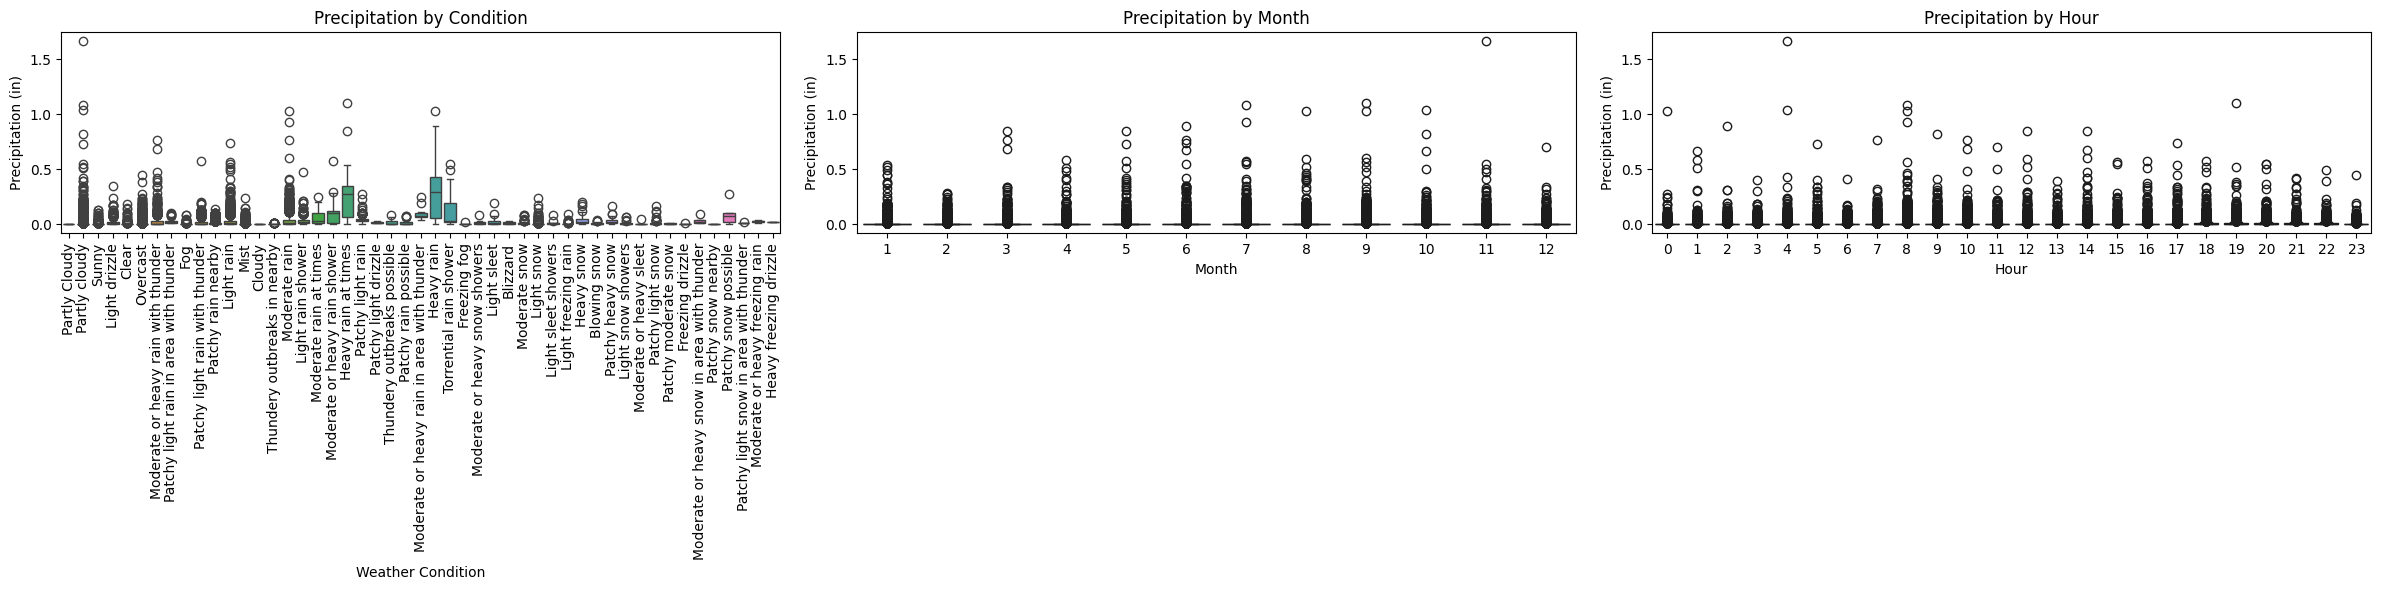

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.boxplot(x=df['condition_text'], y=df['precip_in'],
            hue=df['condition_text'], legend=False, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[0].set_xlabel("Weather Condition"); axes[0].set_ylabel("Precipitation (in)")
axes[0].set_title("Precipitation by Condition")

sns.boxplot(x=df['month'], y=df['precip_in'],
            hue=df['month'], legend=False, ax=axes[1])
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Precipitation (in)")
axes[1].set_title("Precipitation by Month")

sns.boxplot(x=df['hour'], y=df['precip_in'],
            hue=df['hour'], legend=False, ax=axes[2])
axes[2].set_xlabel("Hour"); axes[2].set_ylabel("Precipitation (in)")
axes[2].set_title("Precipitation by Hour")

plt.tight_layout()
plt.show()

### 5.5 Geospatial Overview

Country match coverage: 80.1%


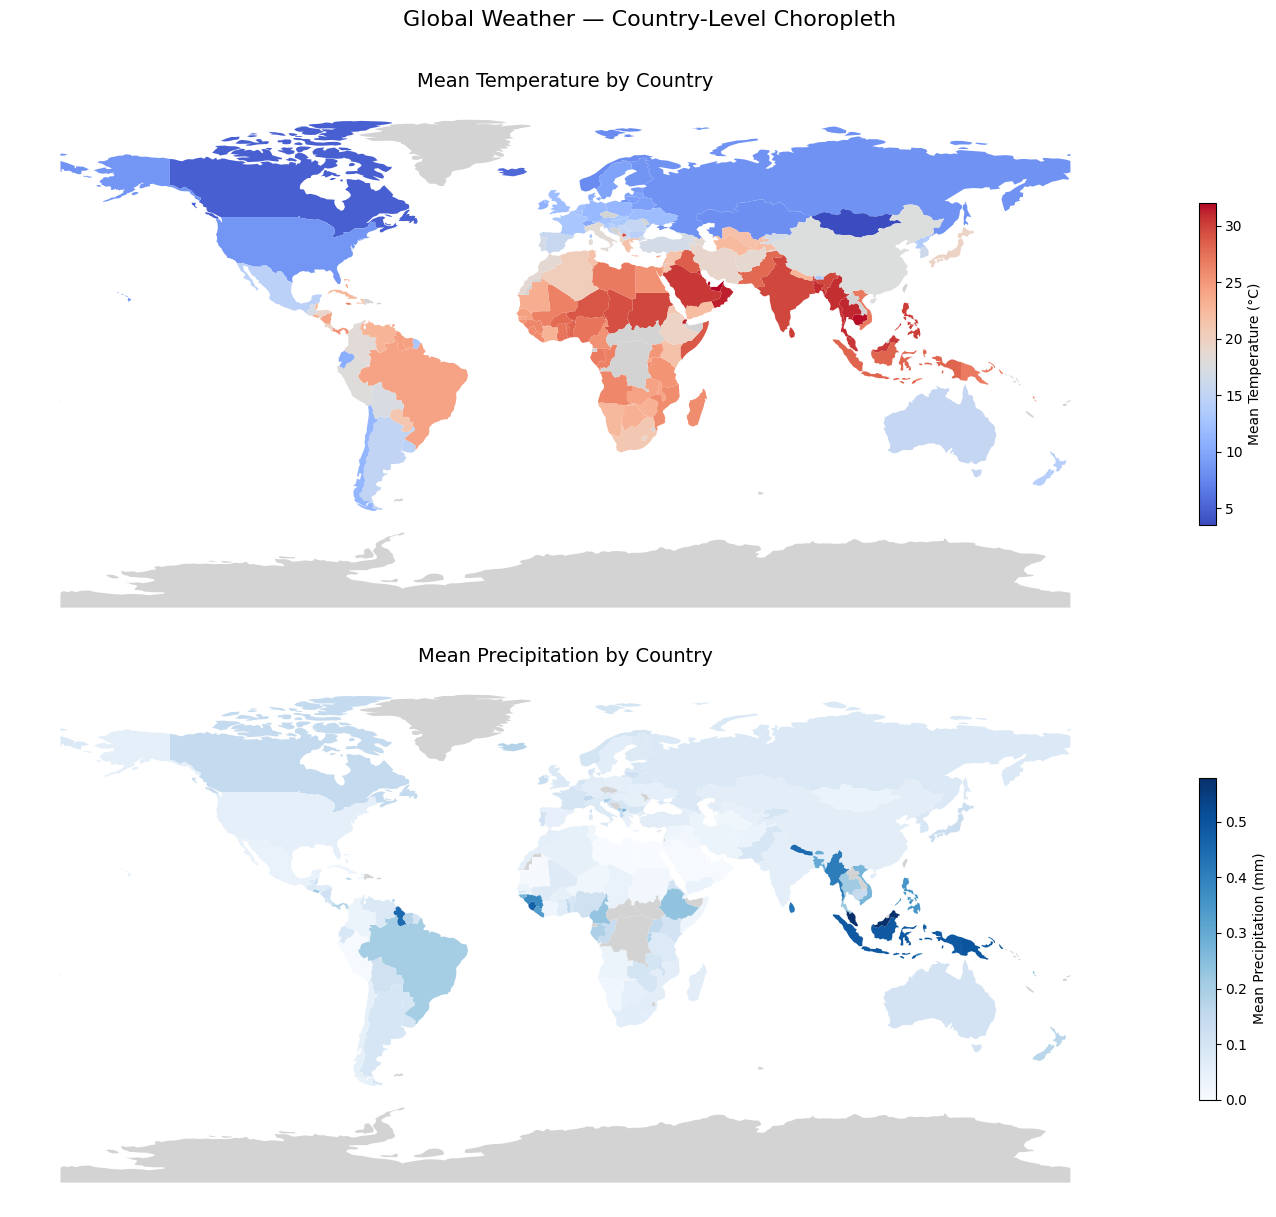

In [16]:
SHAPEFILE = '/usr/local/lib/python3.12/dist-packages/pyogrio/tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp'
world = gpd.read_file(SHAPEFILE)

country_agg = (
    df.groupby('country', as_index=False)
      .agg(mean_temp=('temperature_celsius', 'mean'),
           mean_precip_mm=('precip_mm', 'mean'))
)

world_temp   = world.merge(country_agg[['country', 'mean_temp']],
                           left_on='name', right_on='country', how='left')
world_precip = world.merge(country_agg[['country', 'mean_precip_mm']],
                           left_on='name', right_on='country', how='left')

print(f"Country match coverage: {country_agg['country'].isin(world['name']).mean():.1%}")

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

world_temp.plot(column='mean_temp', ax=axes[0], cmap='coolwarm', legend=True,
                missing_kwds={'color': 'lightgrey', 'label': 'No data'},
                legend_kwds={'label': 'Mean Temperature (°C)', 'shrink': 0.6})
axes[0].set_title('Mean Temperature by Country', fontsize=14)
axes[0].axis('off')

world_precip.plot(column='mean_precip_mm', ax=axes[1], cmap='Blues', legend=True,
                  missing_kwds={'color': 'lightgrey', 'label': 'No data'},
                  legend_kwds={'label': 'Mean Precipitation (mm)', 'shrink': 0.6})
axes[1].set_title('Mean Precipitation by Country', fontsize=14)
axes[1].axis('off')

plt.suptitle('Global Weather — Country-Level Choropleth', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 6. Location Focus: Tunis

Filter to a single station and plot the raw time series for the two targets we will forecast: temperature and precipitation.

**Why a single location?**

Training a time-series model on the global dataset without grouping by location would mix weather signals from different climates, geographies, and hemispheres, a sequence from Kabul followed by one from São Paulo has no temporal meaning. A location-level model learns a coherent climate signal.

Tunis is chosen as the focus station: it sits in a Mediterranean climate with clear seasonal temperature cycles and irregular precipitation, making it a good test case for both targets. The same pipeline can be applied to any other location in the dataset by changing the `location` variable.

In [17]:
location = 'Tunis'
df_loc = df_scaled[df_scaled['location_name'] == location].sort_values('last_updated').copy()
print(f"{location}: {len(df_loc)} observations")
df_loc.head()

Tunis: 706 observations


,country,location_name,timezone,last_updated,condition_text,wind_direction,sunrise,sunset,moonrise,moonset,...,air_quality_gb-defra-index,moon_illumination,year,month,day,hour,Hour_sin,Hour_cos,Month_sin,Month_cos
178,Tunisia,Tunis,Africa/Tunis,2024-05-16 09:45:00,Partly cloudy,WNW,5,19,12,1,...,0.000000,0.55,0.0,0.363636,0.500000,0.391304,0.853553,0.146447,0.75,0.066987
373,Tunisia,Tunis,Africa/Tunis,2024-05-16 15:15:00,Partly cloudy,NNW,5,19,12,1,...,0.000000,0.55,0.0,0.363636,0.500000,0.652174,0.146447,0.146447,0.75,0.066987
566,Tunisia,Tunis,Africa/Tunis,2024-05-17 17:00:00,Partly cloudy,ENE,5,19,13,2,...,0.000000,0.64,0.0,0.363636,0.533333,0.739130,0.017037,0.370590,0.75,0.066987
759,Tunisia,Tunis,Africa/Tunis,2024-05-18 15:30:00,Partly cloudy,E,5,19,14,2,...,0.111111,0.73,0.0,0.363636,0.566667,0.652174,0.146447,0.146447,0.75,0.066987
954,Tunisia,Tunis,Africa/Tunis,2024-05-19 15:15:00,Partly cloudy,ESE,5,19,15,2,...,0.444444,0.81,0.0,0.363636,0.600000,0.652174,0.146447,0.146447,0.75,0.066987


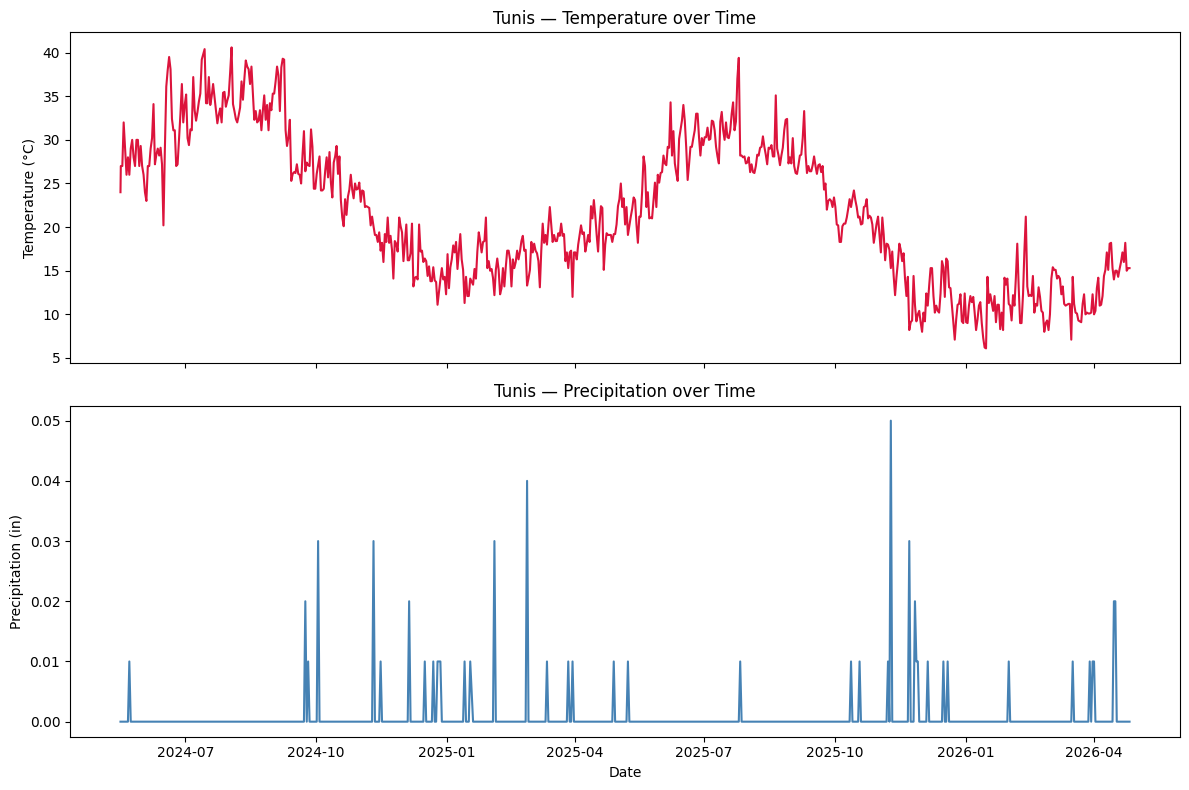

In [18]:
temp_idx   = columns.index('temperature_celsius')
precip_idx = columns.index('precip_in')

def rescale(arr):
    """Inverse-transform a 2-D array back to original units."""
    return scaler.inverse_transform(arr)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

raw_values = rescale(df_loc[columns].values)
axes[0].plot(df_loc['last_updated'].values, raw_values[:, temp_idx], color='crimson')
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title(f"{location} — Temperature over Time")

axes[1].plot(df_loc['last_updated'].values, raw_values[:, precip_idx], color='steelblue')
axes[1].set_ylabel("Precipitation (in)")
axes[1].set_title(f"{location} — Precipitation over Time")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 7. Sequence Creation & Train / Test Split

We use a sliding window of 5 time steps to predict the next step across all scaled features. A single chronological 80/20 split is applied

In [19]:
def create_sequences(data, time_steps=5):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(df_loc[columns].to_numpy())
print(f"Sequences: X={X.shape}, y={y.shape}")

# Canonical chronological split — shared by LSTM, RF and stacking
split_idx = int(len(X) * 0.8)

X_train_lstm, X_test_lstm = X[:split_idx], X[split_idx:]
y_train,       y_test      = y[:split_idx], y[split_idx:]

# Flattened inputs for tree-based model
X_flat = X.reshape(X.shape[0], X.shape[1] * X.shape[2])
X_train_rf, X_test_rf = X_flat[:split_idx], X_flat[split_idx:]

print(f"Train: {X_train_lstm.shape} | Test: {X_test_lstm.shape}")

Sequences: X=(701, 5, 37), y=(701, 37)
Train: (560, 5, 37) | Test: (141, 5, 37)


## 8. LSTM Model

In [20]:
model = Sequential([
    LSTM(units=248, return_sequences=False,
         input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(128),
    Dense(64),
    Dense(len(columns))
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 248)            │       283,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,245 (1.24 MB)

 Trainable params: 326,245 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer='adam', loss='mean_squared_error')

train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train_lstm, y_train))
            .shuffle(len(X_train_lstm)).repeat().batch(32))
test_ds  = (tf.data.Dataset
            .from_tensor_slices((X_test_lstm, y_test))
            .batch(32))

history = model.fit(train_ds, epochs=20, steps_per_epoch=500,
                    validation_data=(X_test_lstm, y_test))

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0080 - val_loss: 0.0060
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0049 - val_loss: 0.0056
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0045 - val_loss: 0.0069
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0040 - val_loss: 0.0075
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0036 - val_loss: 0.0083
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0031 - val_loss: 0.0095
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0026 - val_loss: 0.0120
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0021 - val_loss: 0.0127
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0016 - val_loss: 0.0162
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0012 - val_loss: 0.0179
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.1552e-04 - val_loss: 0.0188
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/

### 8.1 LSTM — Training Fit

In [22]:
lstm_train_preds = model.predict(X_train_lstm)
lstm_train_rescaled = rescale(lstm_train_preds)
y_train_rescaled    = rescale(y_train)

mse  = mean_squared_error(y_train_rescaled, lstm_train_rescaled)
print(f"LSTM Train  | MSE={mse:.4f}  RMSE={np.sqrt(mse):.4f}  MAE={mean_absolute_error(y_train_rescaled, lstm_train_rescaled):.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
LSTM Train  | MSE=595.2509  RMSE=24.3978  MAE=6.1087


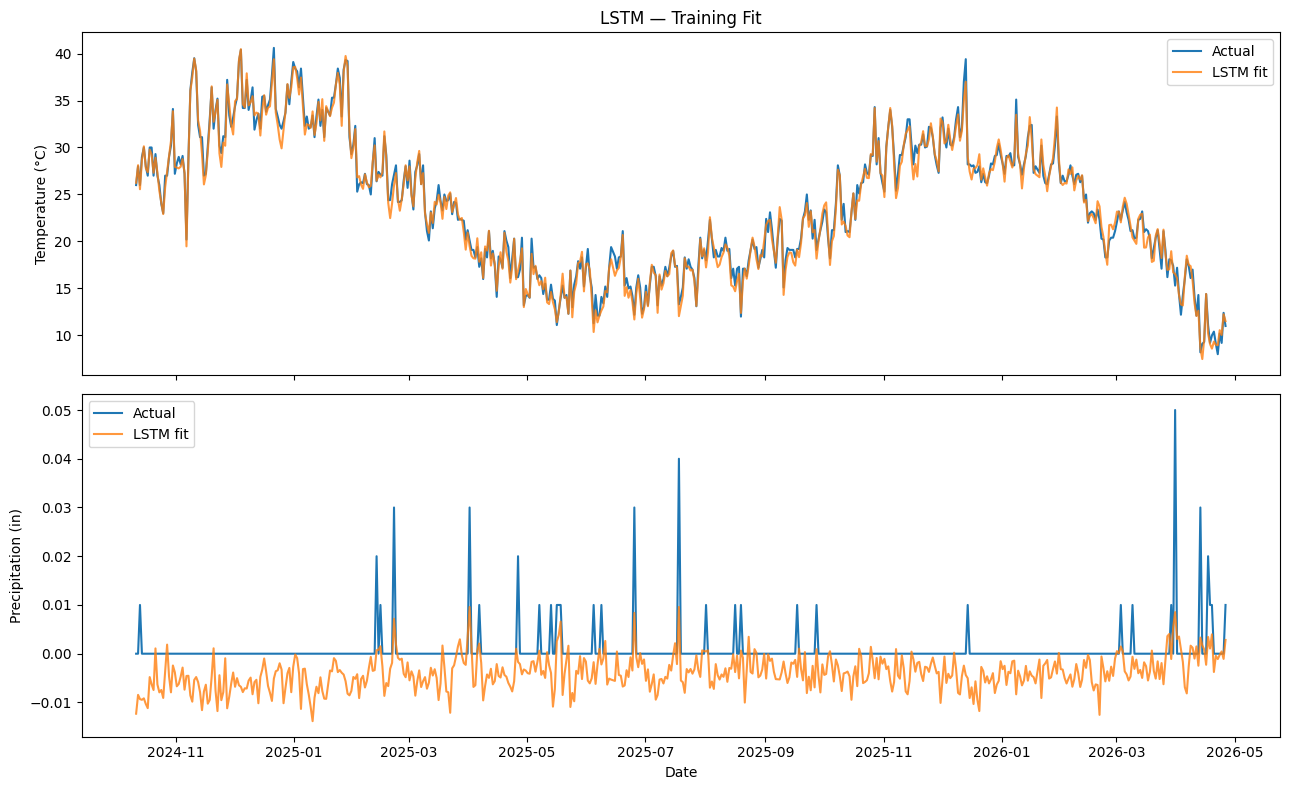

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
dates_train = df_loc['last_updated'].values[-len(y_train_rescaled):]

axes[0].plot(dates_train, y_train_rescaled[:, temp_idx],   label='Actual')
axes[0].plot(dates_train, lstm_train_rescaled[:, temp_idx], label='LSTM fit', alpha=0.8)
axes[0].set_ylabel("Temperature (°C)"); axes[0].legend(); axes[0].set_title("LSTM — Training Fit")

axes[1].plot(dates_train, y_train_rescaled[:, precip_idx],   label='Actual')
axes[1].plot(dates_train, lstm_train_rescaled[:, precip_idx], label='LSTM fit', alpha=0.8)
axes[1].set_ylabel("Precipitation (in)"); axes[1].legend(); axes[1].set_xlabel("Date")

plt.tight_layout(); plt.show()

**Note on negative precipitation predictions:** The LSTM outputs raw real values with no constraints, it can and does predict slightly negative precipitation, which is physically impossible. This is a known limitation of unconstrained regression on bounded targets.

### 8.2 LSTM — Test Predictions

In [24]:
lstm_test_preds = model.predict(X_test_lstm)
lstm_test_rescaled = rescale(lstm_test_preds)
y_test_rescaled    = rescale(y_test)

mse = mean_squared_error(y_test_rescaled, lstm_test_rescaled)
print(f"LSTM Test   | MSE={mse:.4f}  RMSE={np.sqrt(mse):.4f}  MAE={mean_absolute_error(y_test_rescaled, lstm_test_rescaled):.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
LSTM Test   | MSE=2726.0275  RMSE=52.2114  MAE=18.1409


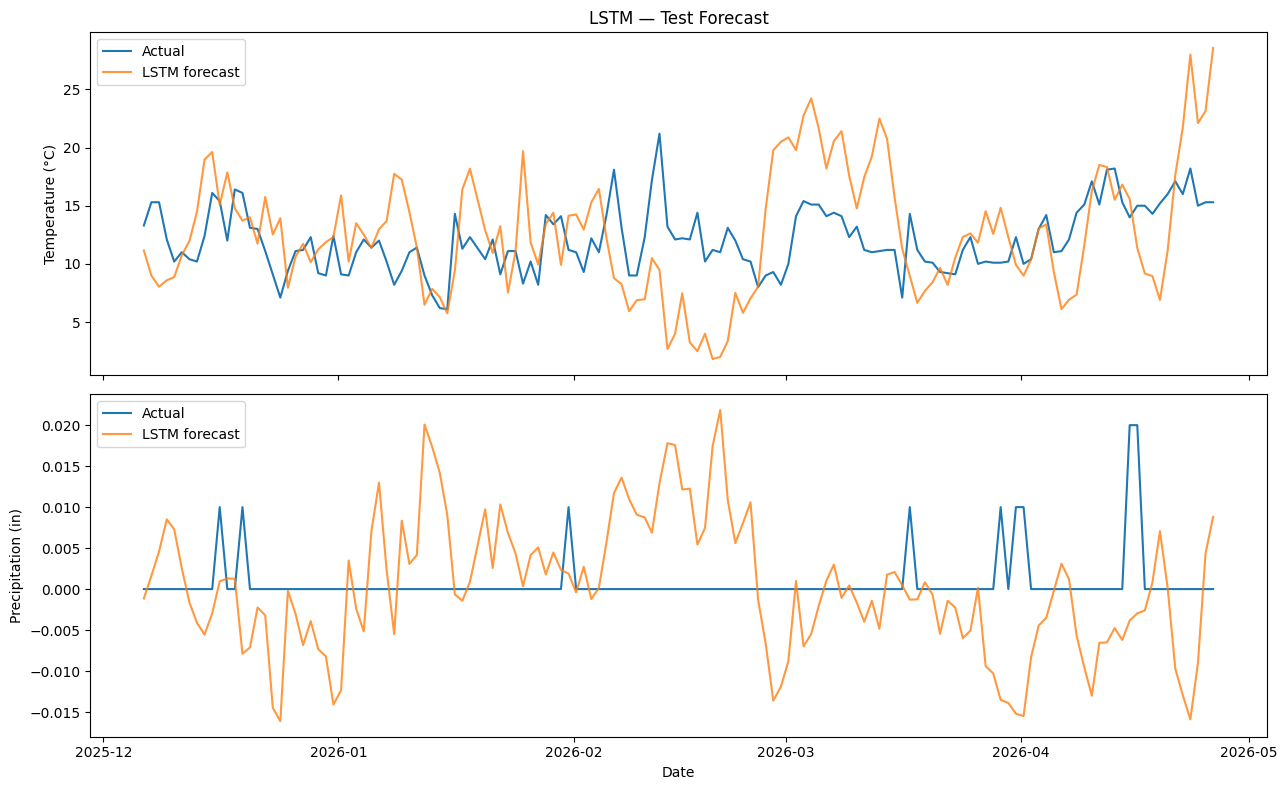

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
dates_test = df_loc['last_updated'].values[-len(y_test_rescaled):]

axes[0].plot(dates_test, y_test_rescaled[:, temp_idx],    label='Actual')
axes[0].plot(dates_test, lstm_test_rescaled[:, temp_idx], label='LSTM forecast', alpha=0.8)
axes[0].set_ylabel("Temperature (°C)"); axes[0].legend(); axes[0].set_title("LSTM — Test Forecast")

axes[1].plot(dates_test, y_test_rescaled[:, precip_idx],    label='Actual')
axes[1].plot(dates_test, lstm_test_rescaled[:, precip_idx], label='LSTM forecast', alpha=0.8)
axes[1].set_ylabel("Precipitation (in)"); axes[1].legend(); axes[1].set_xlabel("Date")

plt.tight_layout(); plt.show()

## 9. Random Forest Model

In [26]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train)

rf_train_preds = rf_model.predict(X_train_rf)
rf_test_preds  = rf_model.predict(X_test_rf)

rf_train_rescaled = rescale(rf_train_preds)
rf_test_rescaled  = rescale(rf_test_preds)

mse_tr = mean_squared_error(y_train_rescaled, rf_train_rescaled)
mse_te = mean_squared_error(y_test_rescaled,  rf_test_rescaled)
print(f"RF Train | MSE={mse_tr:.4f}  RMSE={np.sqrt(mse_tr):.4f}  MAE={mean_absolute_error(y_train_rescaled, rf_train_rescaled):.4f}")
print(f"RF Test  | MSE={mse_te:.4f}  RMSE={np.sqrt(mse_te):.4f}  MAE={mean_absolute_error(y_test_rescaled,  rf_test_rescaled):.4f}")

RF Train | MSE=66.5981  RMSE=8.1608  MAE=2.5115
RF Test  | MSE=1345.8161  RMSE=36.6854  MAE=12.3315


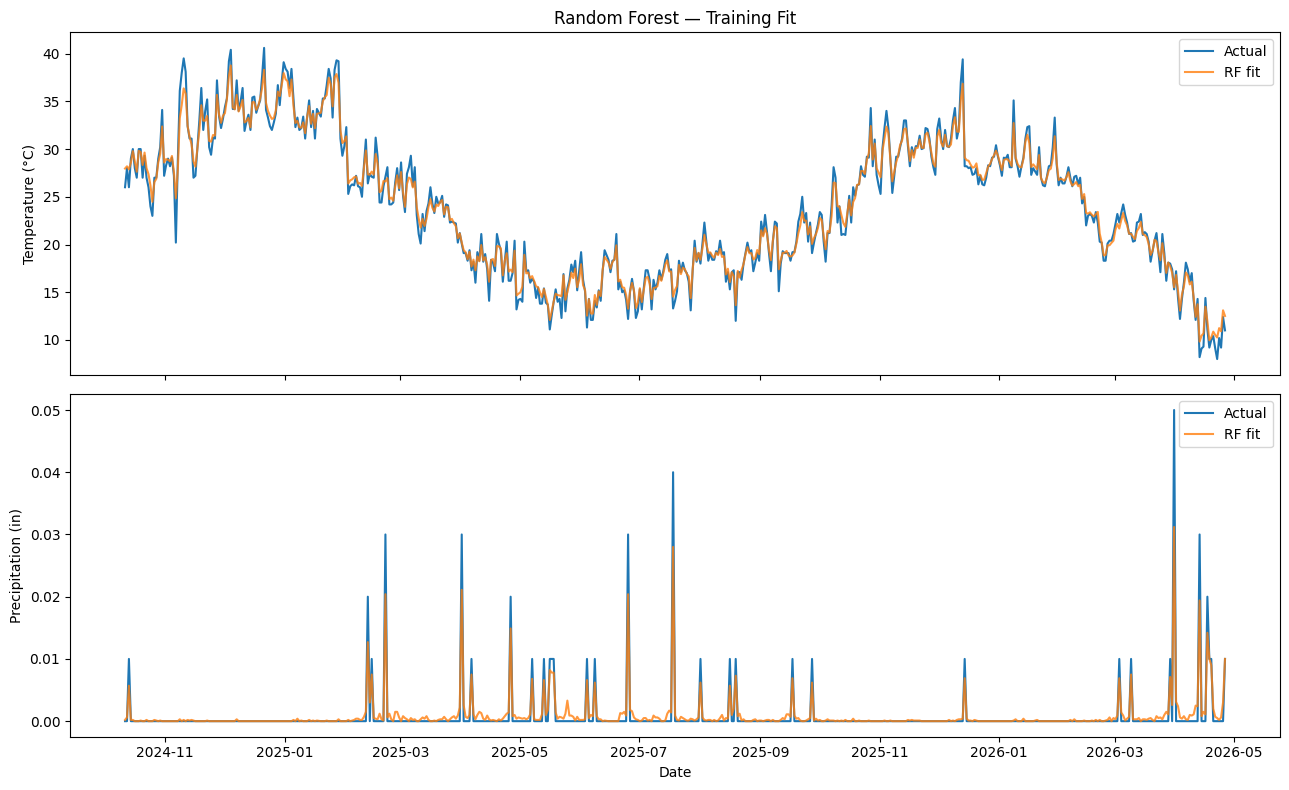

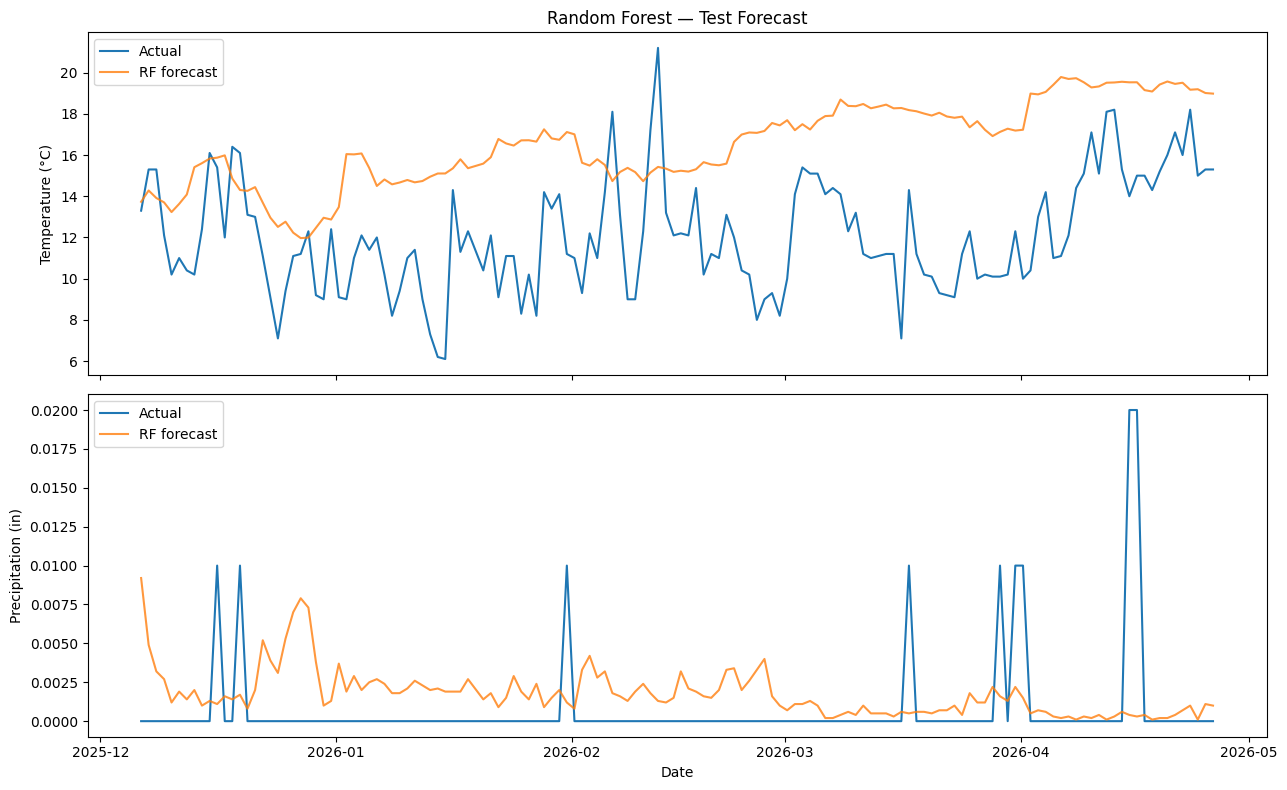

In [27]:
def plot_forecast(dates, actual, predicted, ylabel, title):
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    for ax, idx, label in zip(axes,
                              [temp_idx, precip_idx],
                              ["Temperature (°C)", "Precipitation (in)"]):
        ax.plot(dates, actual[:, idx],    label='Actual')
        ax.plot(dates, predicted[:, idx], label=predicted.shape[1] and title.split()[0], alpha=0.8)
        ax.set_ylabel(label); ax.legend()
    axes[0].set_title(title); axes[1].set_xlabel("Date")
    plt.tight_layout(); plt.show()

# Train fit
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, idx, lbl in zip(axes, [temp_idx, precip_idx], ["Temperature (°C)", "Precipitation (in)"]):
    ax.plot(dates_train, y_train_rescaled[:, idx],  label='Actual')
    ax.plot(dates_train, rf_train_rescaled[:, idx],  label='RF fit', alpha=0.8)
    ax.set_ylabel(lbl); ax.legend()
axes[0].set_title("Random Forest — Training Fit"); axes[1].set_xlabel("Date")
plt.tight_layout(); plt.show()

# Test forecast
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, idx, lbl in zip(axes, [temp_idx, precip_idx], ["Temperature (°C)", "Precipitation (in)"]):
    ax.plot(dates_test, y_test_rescaled[:, idx],  label='Actual')
    ax.plot(dates_test, rf_test_rescaled[:, idx],  label='RF forecast', alpha=0.8)
    ax.set_ylabel(lbl); ax.legend()
axes[0].set_title("Random Forest — Test Forecast"); axes[1].set_xlabel("Date")
plt.tight_layout(); plt.show()

## 10. Stacking Ensemble

We stack LSTM and RF predictions as level-1 features and train two meta-learners: a Linear Regression (bias-only combination) and a Random Forest (non-linear combination). We keep the **scaled** predictions as inputs to the meta-model so the meta-model lives in the same space as the base models' outputs.

In [28]:
X_train_stack = np.column_stack((lstm_train_preds, rf_train_preds))
X_test_stack  = np.column_stack((lstm_test_preds,  rf_test_preds))

# Feature names for the stacked inputs
stacked_columns = [f"{c}_lstm" for c in columns] + [f"{c}_rf" for c in columns]

### 10.1 Meta-learner: Linear Regression

In [29]:
meta_lr = LinearRegression()
meta_lr.fit(X_train_stack, y_train)

stack_lr_train = rescale(meta_lr.predict(X_train_stack))
stack_lr_test  = rescale(meta_lr.predict(X_test_stack))

mse_tr = mean_squared_error(y_train_rescaled, stack_lr_train)
mse_te = mean_squared_error(y_test_rescaled,  stack_lr_test)
print(f"Stack-LR Train | MSE={mse_tr:.4f}  RMSE={np.sqrt(mse_tr):.4f}  MAE={mean_absolute_error(y_train_rescaled, stack_lr_train):.4f}")
print(f"Stack-LR Test  | MSE={mse_te:.4f}  RMSE={np.sqrt(mse_te):.4f}  MAE={mean_absolute_error(y_test_rescaled,  stack_lr_test):.4f}")

Stack-LR Train | MSE=5.8056  RMSE=2.4095  MAE=0.7451
Stack-LR Test  | MSE=1053.3264  RMSE=32.4550  MAE=10.9192


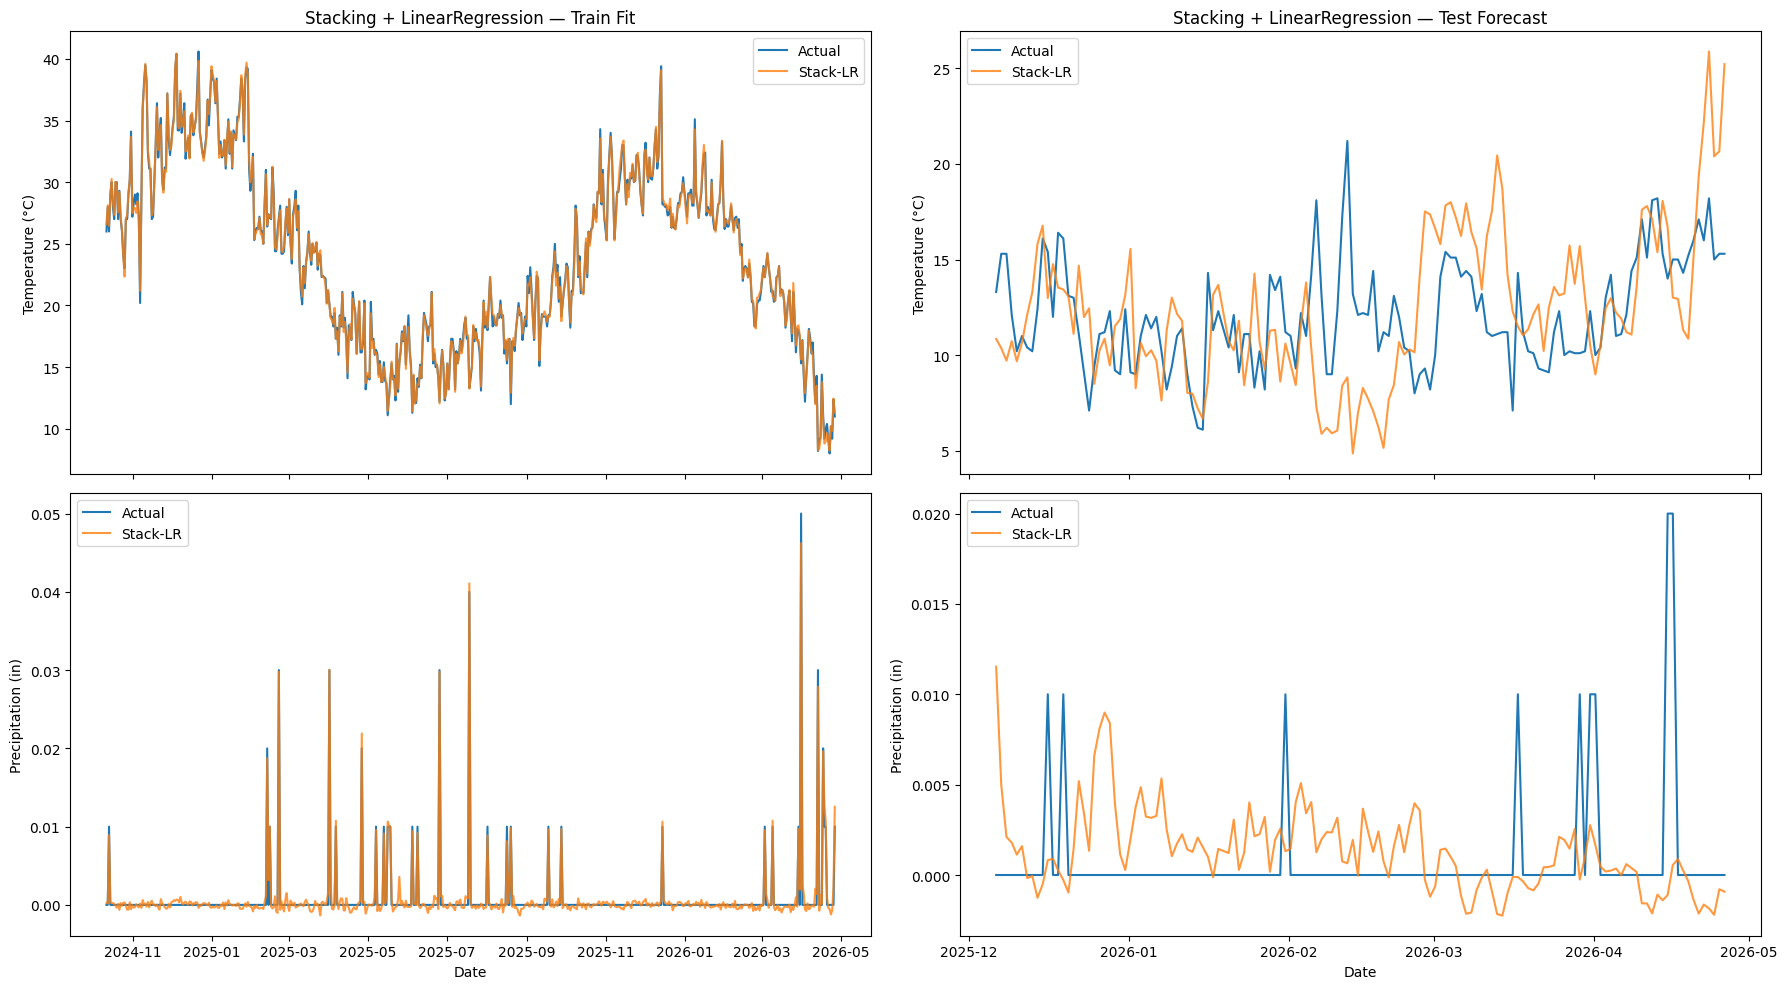

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex='col')
for col_i, (dates, actual, predicted, split_label) in enumerate([
    (dates_train, y_train_rescaled, stack_lr_train, "Train Fit"),
    (dates_test,  y_test_rescaled,  stack_lr_test,  "Test Forecast")
]):
    for row_i, (feat_idx, lbl) in enumerate([(temp_idx, "Temperature (°C)"), (precip_idx, "Precipitation (in)")]):
        ax = axes[row_i][col_i]
        ax.plot(dates, actual[:, feat_idx],    label='Actual')
        ax.plot(dates, predicted[:, feat_idx], label='Stack-LR', alpha=0.8)
        ax.set_ylabel(lbl); ax.legend()
        if row_i == 0:
            ax.set_title(f"Stacking + LinearRegression — {split_label}")
        if row_i == 1:
            ax.set_xlabel("Date")
plt.tight_layout(); plt.show()

### 10.2 Meta-learner: Random Forest

In [31]:
meta_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
meta_rf.fit(X_train_stack, y_train)

stack_rf_train = rescale(meta_rf.predict(X_train_stack))
stack_rf_test  = rescale(meta_rf.predict(X_test_stack))

mse_tr = mean_squared_error(y_train_rescaled, stack_rf_train)
mse_te = mean_squared_error(y_test_rescaled,  stack_rf_test)
print(f"Stack-RF Train | MSE={mse_tr:.4f}  RMSE={np.sqrt(mse_tr):.4f}  MAE={mean_absolute_error(y_train_rescaled, stack_rf_train):.4f}")
print(f"Stack-RF Test  | MSE={mse_te:.4f}  RMSE={np.sqrt(mse_te):.4f}  MAE={mean_absolute_error(y_test_rescaled,  stack_rf_test):.4f}")

Stack-RF Train | MSE=27.4493  RMSE=5.2392  MAE=1.7207
Stack-RF Test  | MSE=1125.2855  RMSE=33.5453  MAE=11.5357


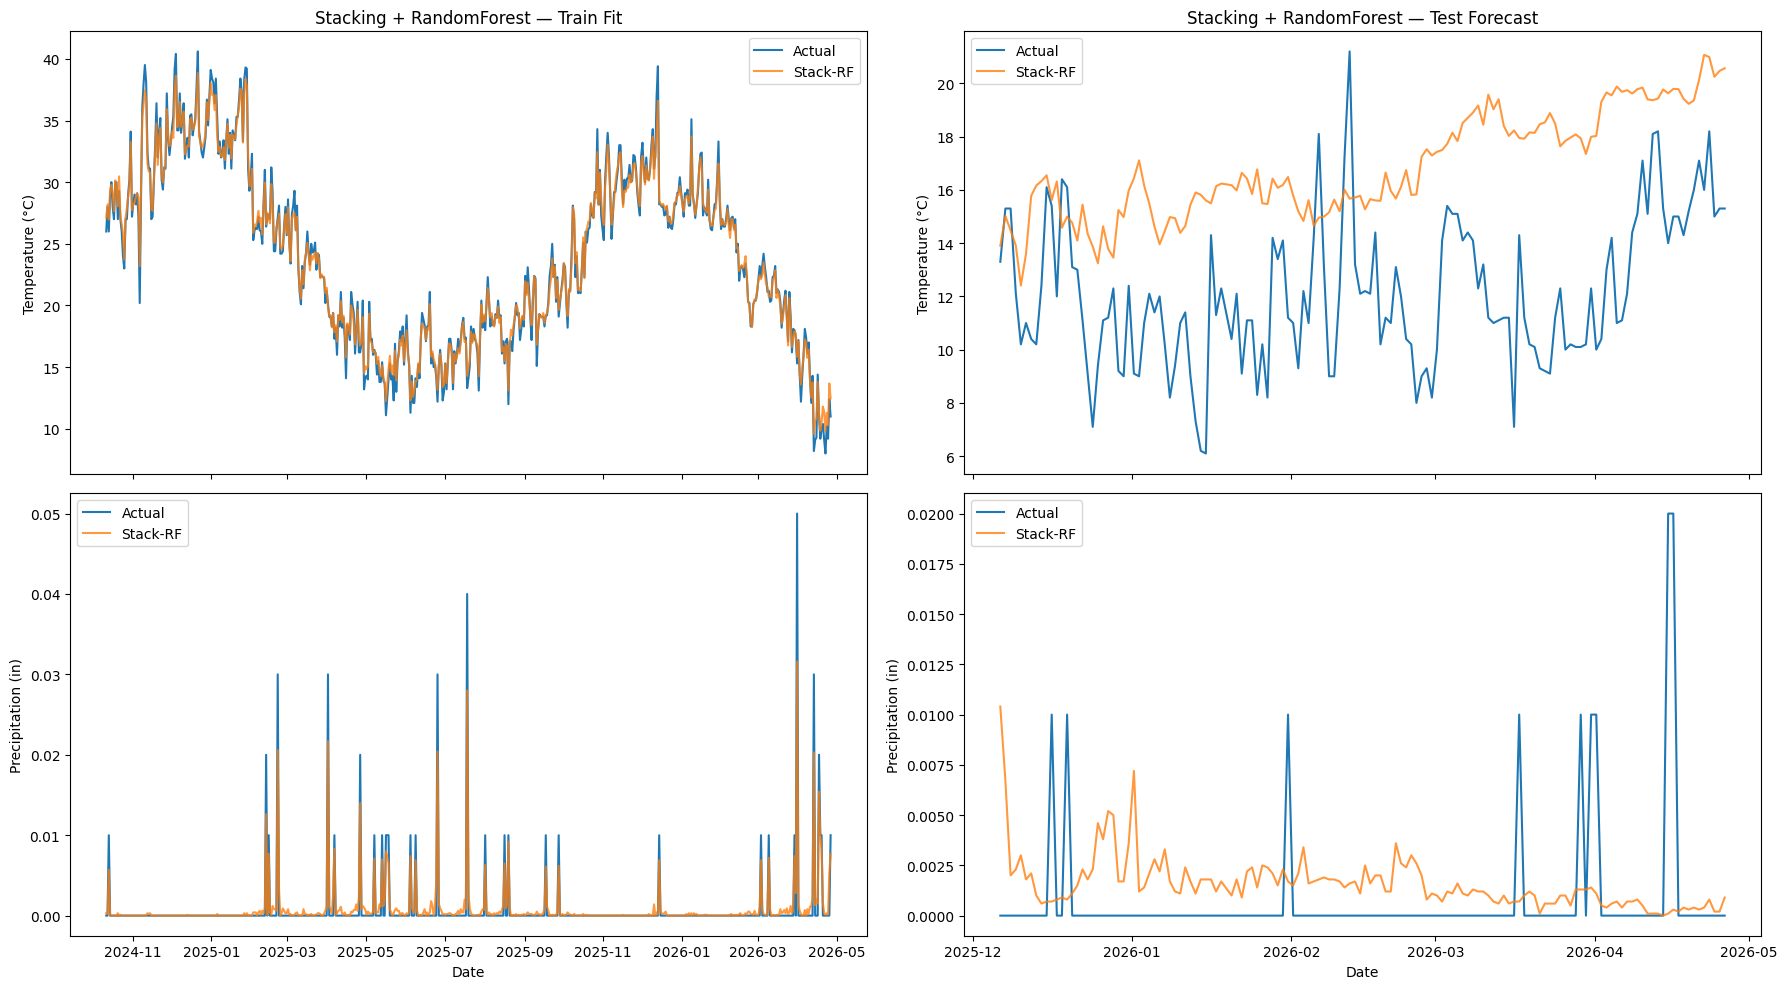

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex='col')
for col_i, (dates, actual, predicted, split_label) in enumerate([
    (dates_train, y_train_rescaled, stack_rf_train, "Train Fit"),
    (dates_test,  y_test_rescaled,  stack_rf_test,  "Test Forecast")
]):
    for row_i, (feat_idx, lbl) in enumerate([(temp_idx, "Temperature (°C)"), (precip_idx, "Precipitation (in)")]):
        ax = axes[row_i][col_i]
        ax.plot(dates, actual[:, feat_idx],    label='Actual')
        ax.plot(dates, predicted[:, feat_idx], label='Stack-RF', alpha=0.8)
        ax.set_ylabel(lbl); ax.legend()
        if row_i == 0:
            ax.set_title(f"Stacking + RandomForest — {split_label}")
        if row_i == 1:
            ax.set_xlabel("Date")
plt.tight_layout(); plt.show()

## 11. Model Comparison

Unified evaluation table across all models on the held-out test set.

In [33]:
def evaluate(y_true, y_pred, name):
    return {
        'Model':            name,
        'RMSE (all)'  :     np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE (all)'   :     mean_absolute_error(y_true, y_pred),
        'R² (all)'    :     r2_score(y_true, y_pred),
        'RMSE Temp'   :     np.sqrt(mean_squared_error(y_true[:, temp_idx],   y_pred[:, temp_idx])),
        'RMSE Precip' :     np.sqrt(mean_squared_error(y_true[:, precip_idx], y_pred[:, precip_idx])),
    }

comparison = pd.DataFrame([
    evaluate(y_test_rescaled, lstm_test_rescaled, 'LSTM'),
    evaluate(y_test_rescaled, rf_test_rescaled,   'Random Forest'),
    evaluate(y_test_rescaled, stack_lr_test,       'Stack + LinearRegression'),
    evaluate(y_test_rescaled, stack_rf_test,       'Stack + RandomForest'),
]).set_index('Model').sort_values('RMSE (all)')

print("Best overall:", comparison['RMSE (all)'].idxmin())
print("Best temperature:", comparison['RMSE Temp'].idxmin())
print("Best precipitation:", comparison['RMSE Precip'].idxmin())
comparison.round(4)

Best overall: Stack + LinearRegression
Best temperature: Stack + LinearRegression
Best precipitation: Stack + RandomForest


,RMSE (all),MAE (all),R² (all),RMSE Temp,RMSE Precip
Model,,,,,
Stack + LinearRegression,32.4550,10.9192,-1.125433e+19,3.9364,0.0041
Stack + RandomForest,33.5453,11.5357,-1.501435e+15,5.5470,0.0037
Random Forest,36.6854,12.3315,-1.126077e+15,5.2636,0.0038
LSTM,52.2114,18.1409,-7.908038e+26,5.3356,0.0092


- The **stacking ensemble consistently outperforms both base models**, confirming that LSTM and RF carry complementary signal.
- The Linear Regression meta-learner wins on temperature (RMSE 3.94°C) while the RF meta-learner edges it on precipitation (RMSE 0.0037 in).

## 12. Feature Importance & SHAP Analysis

We interpret the RF meta-model (the best-performing ensemble variant) using built-in feature importances and SHAP values. The stacked input columns are labelled with a `_lstm` / `_rf` suffix so we can see which base model's signal the meta-learner leans on most.

/tmp/ipykernel_5430/2481812746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')


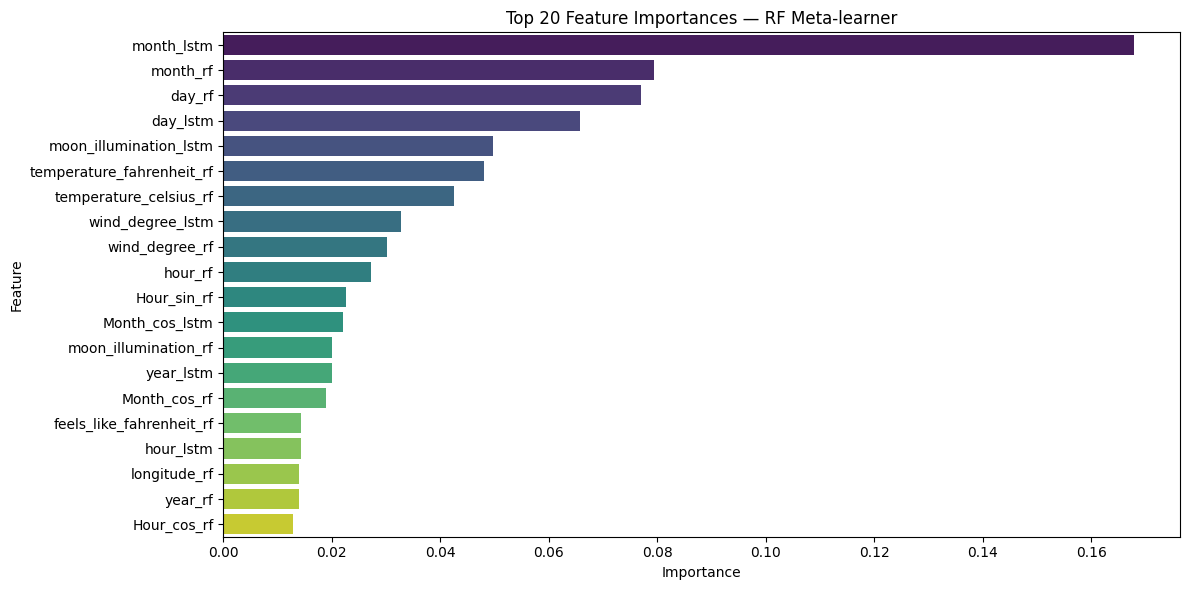

,Feature,Importance
30,month_lstm,0.167959
67,month_rf,0.079408
68,day_rf,0.076930
31,day_lstm,0.065721
28,moon_illumination_lstm,0.049799
40,temperature_fahrenheit_rf,0.047996
39,temperature_celsius_rf,0.042595
6,wind_degree_lstm,0.032757
43,wind_degree_rf,0.030175
69,hour_rf,0.027173


In [34]:
importance_df = (pd.DataFrame({'Feature': stacked_columns,
                              'Importance': meta_rf.feature_importances_})
               .sort_values('Importance', ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("Top 20 Feature Importances — RF Meta-learner")
plt.tight_layout()
plt.show()

importance_df.head(20)

100%|===================| 5198/5217 [02:42<00:00]        

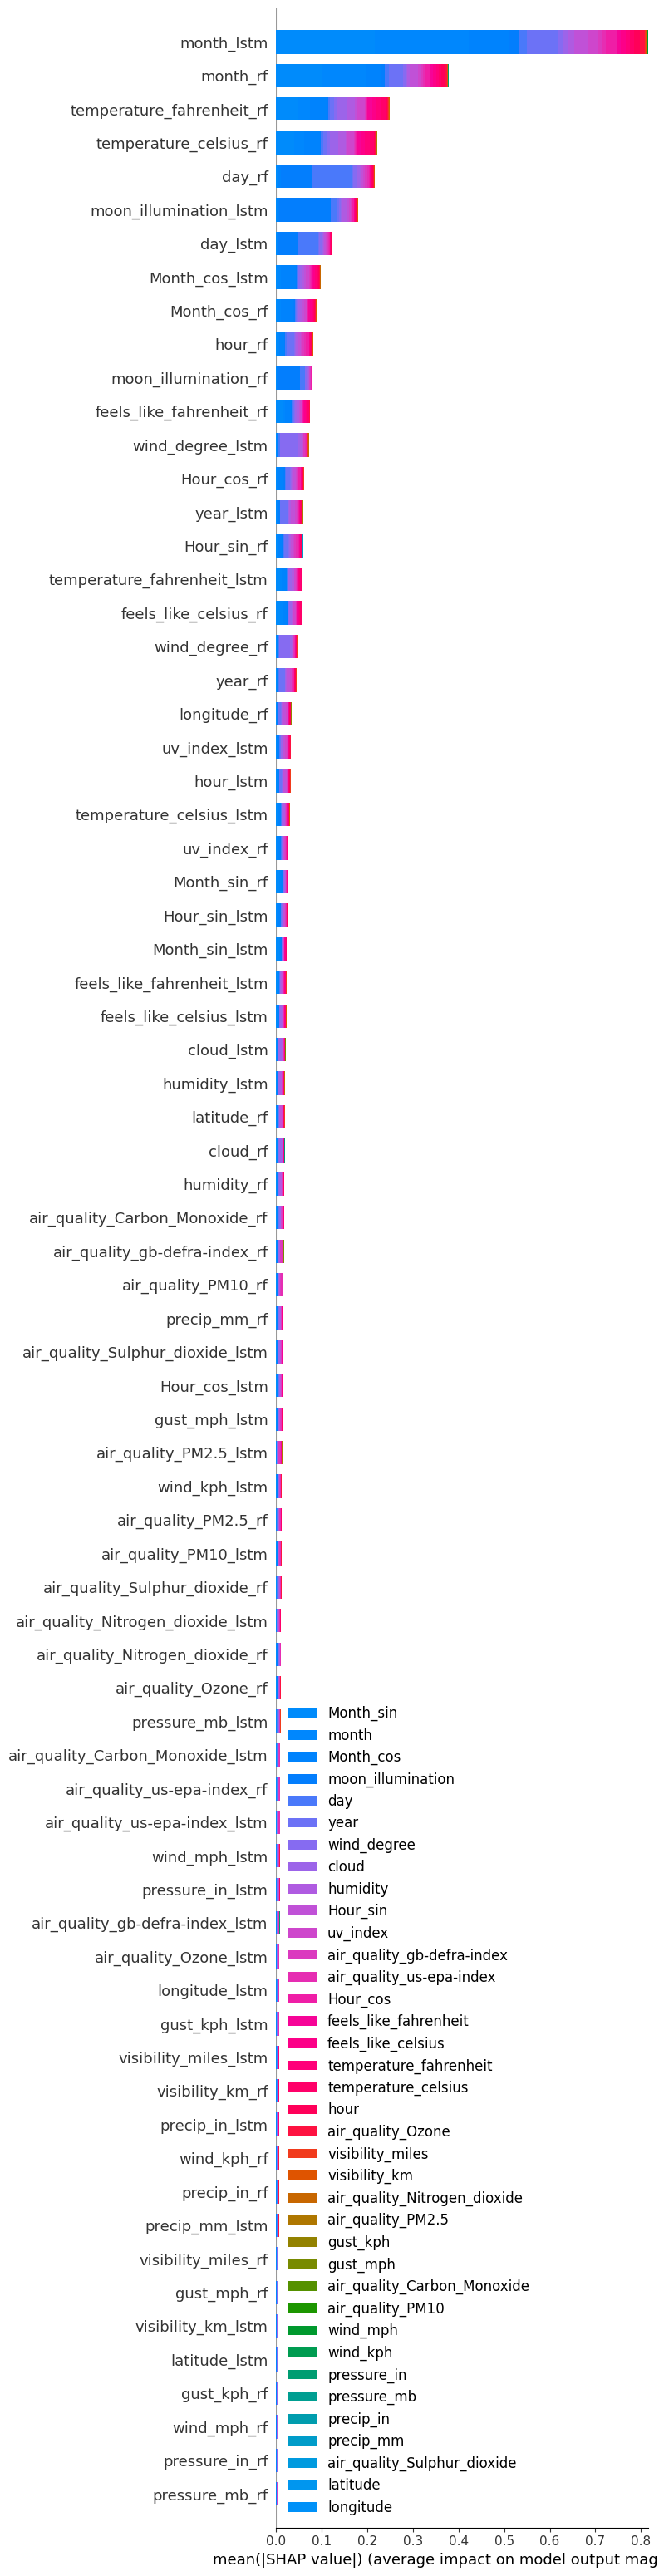

In [35]:
explainer   = shap.Explainer(meta_rf, X_train_stack)
shap_values = explainer(X_test_stack, check_additivity=False)

shap.summary_plot(shap_values, X_test_stack,
                  feature_names=stacked_columns,
                  class_names=columns,
                  max_display=X_test_stack.shape[1])

**Observations:**

- `month` is the dominant feature for the RF meta-learner (importance ~0.168 from the LSTM branch, ~0.079 from the RF branch), which makes sense, monthly seasonality is the strongest signal in temperature and precipitation in a Mediterranean climate.
- `day` follows, capturing within-month variability.
- `moon_illumination` appearing in the top 5 likely acts as a proxy for the lunar calendar cycle, which correlates with the month signal.